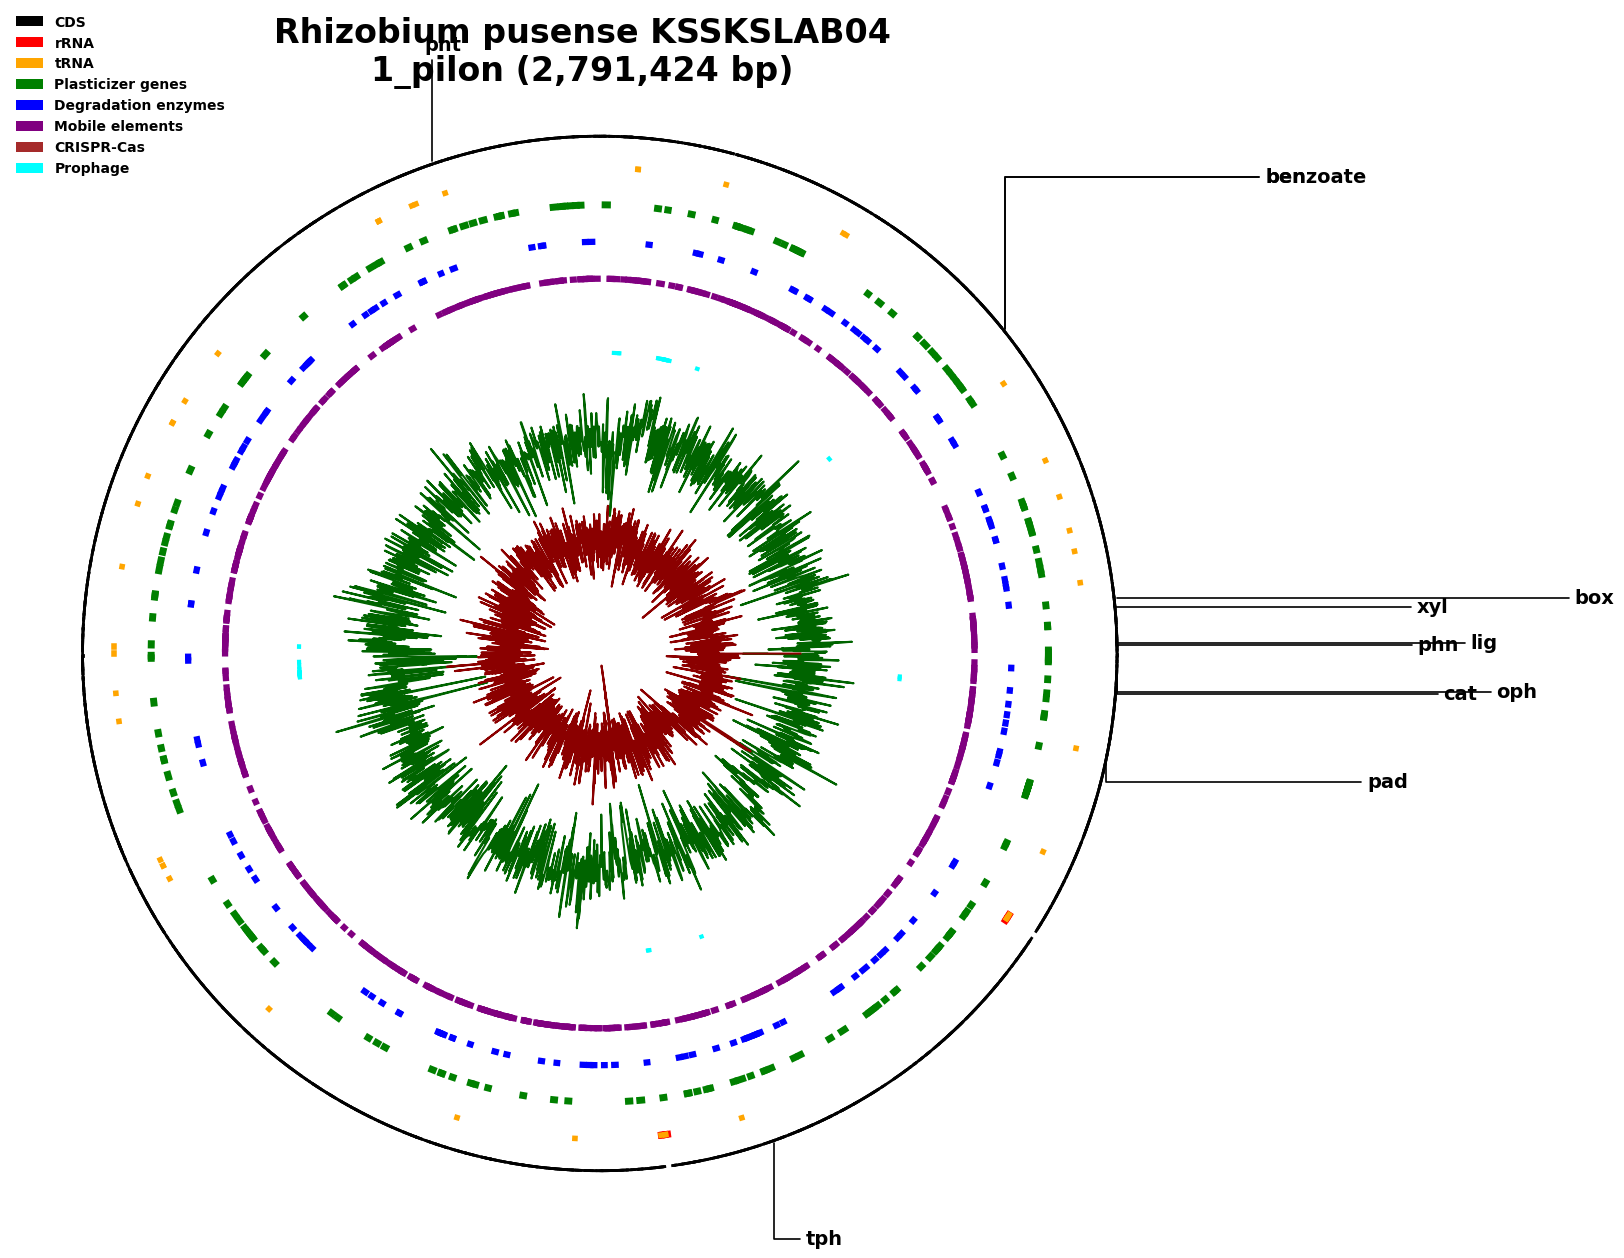

In [8]:
import os
import math
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


os.chdir(r"C:\Users\Anuraj\Desktop\Genome ciruclar map")

genome_fasta = "unicycler_polished.fasta"
gff_file     = "KSSKSLAB04.gff3"
GC_WINDOW    = 1000

plasticizer_cluster = [
    "pht","oph","tph","pca","cat","ben","box","lig",
    "phthalate","protocatechuate","catechol",
    "benzoate","phn","pad","nah","xyl"
]

degradation_enzymes = [
    "esterase","carboxylesterase","arylesterase",
    "lipase","dioxygenase","monooxygenase","oxygenase",
    "dehydrogenase","hydrolase"
]

mobile_elements = [
    "transposase","integrase","recombinase",
    "insertion sequence","conjugative",
    "plasmid protein","relaxase","tra","mob"
]

crispr_terms = ["crispr","cas1","cas2","cas3","cas9"]

prophage_terms = [
    "phage","prophage","capsid","tail",
    "portal","terminase","holin","lysin"
]


def read_fasta(path):
    seqs = {}
    name = None
    parts = []
    for line in open(path):
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if name:
                seqs[name] = "".join(parts).upper()
            name = line[1:].split()[0]
            parts = []
        else:
            parts.append(line)
    if name:
        seqs[name] = "".join(parts).upper()
    return seqs

def parse_gff3(path):
    feats = defaultdict(list)
    for line in open(path):
        if line.startswith("#") or not line.strip():
            continue
        c = line.split("\t")
        if len(c) != 9:
            continue
        sid, src, typ, start, end, score, strand, phase, attrs = c
        attrd = {}
        for kv in attrs.split(";"):
            if "=" in kv:
                k, v = kv.split("=", 1)
                attrd[k] = v.strip()
        feats[sid].append({
            "type": typ,
            "start": int(start),
            "end": int(end),
            "strand": strand,
            "attrs": attrd
        })
    return feats

def classify_feature(f):
    txt = " ".join(f["attrs"].values()).lower()
    if any(k in txt for k in plasticizer_cluster):
        return "plastic"
    if any(k in txt for k in degradation_enzymes):
        return "enzyme"
    if any(k in txt for k in mobile_elements):
        return "mobile"
    if any(k in txt for k in crispr_terms):
        return "crispr"
    if any(k in txt for k in prophage_terms):
        return "prophage"
    return None

def gc_content(s):
    g, c = s.count("G"), s.count("C")
    a, t = s.count("A"), s.count("T")
    tot = a + t + g + c
    return (g + c) / tot if tot else 0

def gc_skew(s):
    g, c = s.count("G"), s.count("C")
    return (g - c) / (g + c) if (g + c) else 0

def angle(p, L):
    return math.radians(90) - (2 * math.pi) * (p / L)

def draw_ring(ax, features, L, r, color, lw):
    for f in features:
        s, e = f["start"], f["end"]
        n = max(15, int((e - s) / max(1, L / 6000)))
        theta = [angle(s + (e - s) * i / (n - 1), L) for i in range(n)]
        ax.plot(theta, [r] * len(theta), color=color, linewidth=lw)


seqs = read_fasta(genome_fasta)
feats = parse_gff3(gff_file)

contig = max(seqs, key=lambda x: len(seqs[x]))
seq = seqs[contig]
L = len(seq)


sid = max(feats.keys(), key=lambda k: max(f["end"] for f in feats[k]))
flist = feats[sid]
if contig != sid:
    print(f"Warning: FASTA contig '{contig}' != GFF contig '{sid}'")


cds  = [f for f in flist if f["type"] == "CDS"]
rrna = [f for f in flist if f["type"] == "rRNA"]
trna = [f for f in flist if f["type"] == "tRNA"]

plastic, enzyme, mobile, crispr, prophage = [], [], [], [], []
for f in cds:
    c = classify_feature(f)
    if c == "plastic":   plastic.append(f)
    elif c == "enzyme":  enzyme.append(f)
    elif c == "mobile":  mobile.append(f)
    elif c == "crispr":  crispr.append(f)
    elif c == "prophage": prophage.append(f)


centers, gc, skew = [], [], []
for i in range(0, L, GC_WINDOW):
    w = seq[i:i + GC_WINDOW]
    centers.append(i + len(w) / 2)
    gc.append(gc_content(w))
    skew.append(gc_skew(w))

gc_mean = sum(gc) / len(gc)
gc_dev = [v - gc_mean for v in gc]
gc_range = max(abs(min(gc_dev)), abs(max(gc_dev)))
gc_scale = 0.18 / gc_range if gc_range != 0 else 1

skew_range = max(abs(min(skew)), abs(max(skew)))
skew_scale = 0.18 / skew_range if skew_range != 0 else 1


fig = plt.figure(figsize=(14, 14))
ax = plt.subplot(111, projection="polar")
ax.set_theta_direction(-1)
ax.set_theta_zero_location("N")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)
ax.spines["polar"].set_visible(False)


draw_ring(ax, cds,      L, 0.98, "black",  2)
draw_ring(ax, rrna,     L, 0.92, "red",    5)
draw_ring(ax, trna,     L, 0.92, "orange", 4)
draw_ring(ax, plastic,  L, 0.85, "green",  5)
draw_ring(ax, enzyme,   L, 0.78, "blue",   4.5)
draw_ring(ax, mobile,   L, 0.71, "purple", 4.5)
draw_ring(ax, crispr,   L, 0.64, "brown",  3)
draw_ring(ax, prophage, L, 0.57, "cyan",   3)


label_positions = []
for term in plasticizer_cluster:
    for f in cds:
        combined = " ".join(f["attrs"].values()).lower()
        if term in combined:
            mid = (f["start"] + f["end"]) / 2
            theta = angle(mid, L)
            label_positions.append((theta, term))
            break

label_positions.sort(key=lambda x: x[0])
used_positions = []


gene_heights = {
    "pht": 1.20,
    "tph": 1.20,
    "oph": 1.70,
    "cat": 1.60,
    "pad": 1.55,
    "lig": 1.65,
    "box": 1.85,
    "xyl": 1.55
}

for theta, label in label_positions:
    height = gene_heights.get(label, 1.55)  

    
    if np.cos(theta) > 0:
        theta_shift = 0.05
        ha = "left"
        angleA = 0
        angleB = 90
    else:
        theta_shift = -0.05
        ha = "right"
        angleA = 180
        angleB = 90

    ax.annotate(
        label,
        xy=(theta, 0.98),
        xytext=(theta + theta_shift, height),
        ha=ha,
        va="center",
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            lw=1.2,
            color="black",
            connectionstyle=f"angle,angleA={angleA},angleB={angleB}"
        )
    )
    used_positions.append((theta, height))


ax.plot([angle(p, L) for p in centers],
        [0.40 + d * gc_scale for d in gc_dev],
        color="darkgreen", linewidth=1.5)
ax.plot([angle(p, L) for p in centers],
        [0.20 + s * skew_scale for s in skew],
        color="darkred", linewidth=1.5)

legend_elements = [
    Patch(facecolor="black",  label="CDS"),
    Patch(facecolor="red",    label="rRNA"),
    Patch(facecolor="orange", label="tRNA"),
    Patch(facecolor="green",  label="Plasticizer genes"),
    Patch(facecolor="blue",   label="Degradation enzymes"),
    Patch(facecolor="purple", label="Mobile elements"),
    Patch(facecolor="brown",  label="CRISPR-Cas"),
    Patch(facecolor="cyan",   label="Prophage")
]

ax.legend(handles=legend_elements,
          loc="upper left",
          bbox_to_anchor=(-0.05, 1.10),
          ncol=1,
          frameon=False,
          fontsize=14,
          prop={'weight':'bold'})


fig.suptitle(
    f"Rhizobium pusense KSSKSLAB04\n{contig} ({L:,} bp)",
    fontsize=24,
    fontweight="bold",
    y=0.96
)
plt.subplots_adjust(top=0.90)


plt.savefig("Final genome map.png", dpi=300, bbox_inches="tight")
plt.show()
